# Módulo 6 — Regresión Lineal con Insurance
**Diagnóstico y Predictibilidad | 92-0030 | Prof. Robin Sequeira**

---

### Antes de ejecutar cualquier celda, respondan esto en grupo:

> *¿Pueden predecir cuánto va a gastar una persona en salud solo con saber su edad, peso y si fuma?*

Anoten su hipótesis aquí abajo. Al final del notebook vamos a comparar.

**Nuestra hipótesis:** Se puede predecir porque son variables que pueden inferir en otras enfermedades, pero esa predicción no sería precisa porque consideramos que se requieren mas variables

---
## Paso 1 — Cargar herramientas y datos
Ejecuten esta celda. Si aparece ✅, estamos listos para empezar.

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Cargamos el dataset desde Databricks
df_raw = spark.table('workspace.diagnosticopredictibilidad.insurance').toPandas()
df = df_raw.copy()

print(f'✅ Dataset cargado: {df.shape[0]} personas, {df.shape[1]} variables')
df.head()

✅ Dataset cargado: 1338 personas, 7 variables


,age,sex,bmi,children,smoker,region,charges
0,58,male,16.89,0,no,northeast,11568.40
1,23,female,17.14,0,no,northeast,2975.66
2,53,male,42.57,2,no,southwest,11644.75
3,18,male,41.91,0,yes,southeast,49904.39
4,24,male,30.08,0,no,southeast,8440.50


---
## Paso 2 — Explorar los datos

Antes de construir cualquier modelo, necesitamos entender qué hay en el dataset.

**Ejecuten y respondan:**

In [0]:
# ¿Hay nulos o duplicados?
print(f'Nulos: {df.isna().sum().sum()}  |  Duplicados: {df.duplicated().sum()}')
print()
# ¿Cómo están distribuidos los costos médicos?
print('Estadísticos de charges (costo médico en USD):')
print(df['charges'].describe().round(2).to_string())

Nulos: 0  |  Duplicados: 0

Estadísticos de charges (costo médico en USD):
count     1338.00
mean     19605.36
std      16730.21
min       2107.24
25%       9777.38
50%      12835.09
75%      16953.34
max      69931.71


**¿Qué notan?** _(completen)_
- El costo mínimo es: 2107.24
- El costo máximo es: 69931.71
- El promedio es: 19605.36
- ¿La mediana es muy diferente al promedio? SI 
¿Qué sugiere eso?
Que la mayoria de los asegurados tienen gastos bajos, porque la mitad paga 12.835. Esto sugiere una fuerte asimetria positiva (sesgo a la derecha).


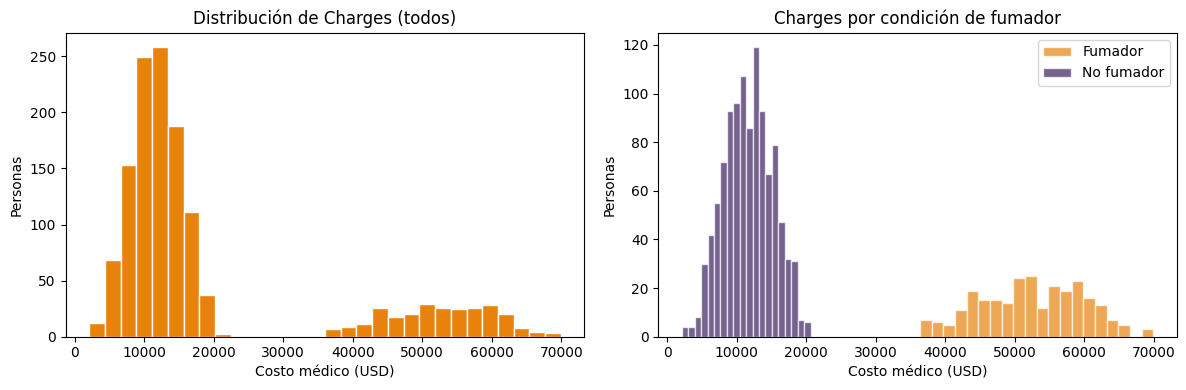

Promedio fumadores:    $52,405
Promedio no fumadores: $11,694
Diferencia:            $40,711


In [0]:
# Veamos la distribución de costos separada por fumador y no fumador
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['charges'], bins=30, color='#E8820C', edgecolor='white')
axes[0].set_title('Distribución de Charges (todos)')
axes[0].set_xlabel('Costo médico (USD)')
axes[0].set_ylabel('Personas')

fuma    = df[df['smoker'] == 'yes']['charges']
no_fuma = df[df['smoker'] == 'no']['charges']
axes[1].hist(fuma,    bins=20, alpha=0.7, color='#E8820C', label='Fumador',    edgecolor='white')
axes[1].hist(no_fuma, bins=20, alpha=0.7, color='#3B1F5E', label='No fumador', edgecolor='white')
axes[1].set_title('Charges por condición de fumador')
axes[1].set_xlabel('Costo médico (USD)')
axes[1].set_ylabel('Personas')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Promedio fumadores:    ${fuma.mean():,.0f}')
print(f'Promedio no fumadores: ${no_fuma.mean():,.0f}')
print(f'Diferencia:            ${fuma.mean() - no_fuma.mean():,.0f}')

**Discutan en grupo:**
- ¿Cuánto más gasta en promedio un fumador? $52,405
- ¿Creen que `smoker` va a ser la variable más importante del modelo? Si, porque la diferencia es de $40.711
- ¿Por qué la distribución del gráfico izquierdo tiene dos picos? Porque existe una variable (fumado) que hace que la totalidad de la poplación se divida en dos extremos.

---
## Paso 3 — Preparar los datos para el modelo

El modelo necesita:
- **y** → lo que queremos predecir (`charges`)
- **X** → todo lo demás (las variables que usa para predecir)

También separamos las columnas por tipo porque cada tipo necesita un tratamiento diferente.

In [0]:
y = df['charges']
X = df.drop(columns=['charges'])

# Numéricas: se escalan para que estén en la misma unidad
num_cols = ['age', 'bmi', 'children']

# Categóricas: se convierten en columnas de 0 y 1
# (el modelo no puede leer 'male' o 'female', pero sí puede leer 1 y 0)
cat_cols = ['sex', 'smoker', 'region']

print(f'Variable a predecir: charges')
print(f'Numéricas:   {num_cols}')
print(f'Categóricas: {cat_cols}')

Variable a predecir: charges
Numéricas:   ['age', 'bmi', 'children']
Categóricas: ['sex', 'smoker', 'region']


---
## Paso 4 — Dividir en entrenamiento y prueba

**Regla importante:** dividimos ANTES de transformar nada.  
Si transformamos primero, el modelo vería datos que no debería → **data leakage** (fuga de datos).

In [0]:
# 80% para que el modelo aprenda, 20% para evaluar si realmente aprendió
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'El modelo va a aprender con: {X_train.shape[0]} personas')
print(f'Lo vamos a evaluar con:      {X_test.shape[0]} personas que nunca vio')

El modelo va a aprender con: 1070 personas
Lo vamos a evaluar con:      268 personas que nunca vio


---
## Paso 5 — Construir y entrenar el modelo

Usamos un **Pipeline** que hace todo en orden automáticamente:
1. Escala los números
2. Convierte el texto en 0s y 1s
3. Entrena la regresión lineal

In [0]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(),                       num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
])

pipe_lr = Pipeline(steps=[
    ('prep',  preprocessor),
    ('model', LinearRegression()),
])

# El modelo aprende solo con los datos de entrenamiento
pipe_lr.fit(X_train, y_train)
print('✅ Modelo entrenado. Ahora vamos a ver qué tan bien predice.')

✅ Modelo entrenado. Ahora vamos a ver qué tan bien predice.


---
## Paso 6 — ¿Qué tan bien predice el modelo?

Evaluamos sobre los datos de **prueba** (los que el modelo nunca vio).

- **MAE** → error promedio en dólares
- **RMSE** → castiga más los errores grandes
- **R²** → qué proporción de la variación en costos logra explicar el modelo (de 0 a 1)

In [0]:
y_pred_lr = pipe_lr.predict(X_test)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print('REGRESIÓN LINEAL — resultados sobre datos de prueba:')
print(f'  MAE:  ${mae_lr:,.0f}   → en promedio nos equivocamos este monto por persona')
print(f'  RMSE: ${rmse_lr:,.0f}  → penaliza más los errores grandes')
print(f'  R²:   {r2_lr:.3f}    → el modelo explica el {r2_lr*100:.1f}% de la variación en costos')

REGRESIÓN LINEAL — resultados sobre datos de prueba:
  MAE:  $2,434   → en promedio nos equivocamos este monto por persona
  RMSE: $3,280  → penaliza más los errores grandes
  R²:   0.962    → el modelo explica el 96.2% de la variación en costos


**Discutan en grupo:**
- Si el MAE es $4,500 y una prima mensual promedio es $350 ($4,200/año), ¿ese error es aceptable para una aseguradora?

    No, porque consideramos que el MAE de 4500 es mayor que la prima de 4.200, lo que haria incurrir en perdida a la aseguradora.
- ¿Qué significa un R²=0.75 en términos del negocio?

    Que con el 75% de la variable Charge (facturas medicas) se puede predecir usando los datos que tenemos (edad, fumadores, IMC)

- ¿Esperaban un número más alto o más bajo?

    Esperaba un valor mas bajo, porque con solo estas tres variables es dificil predecir.

---
## Paso 7 — Ver dónde se equivoca el modelo

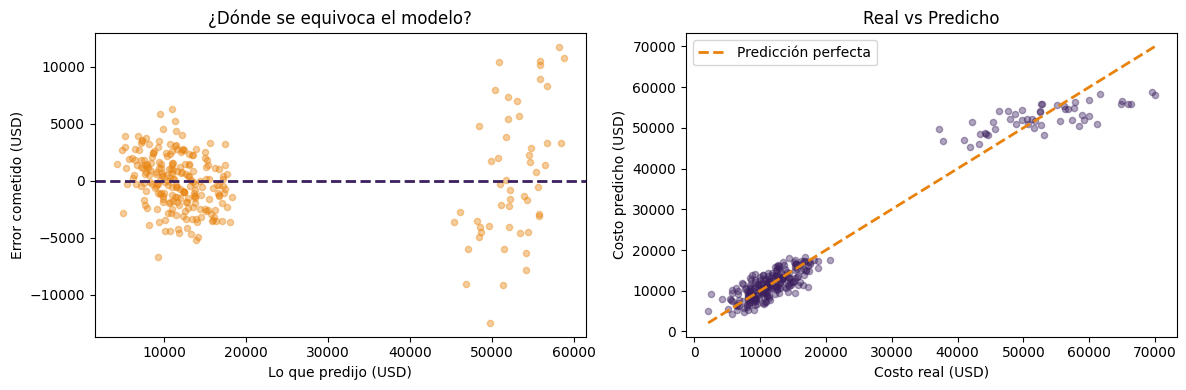

In [0]:
# Residual = lo real - lo que predijo el modelo
# Si el modelo es bueno, los errores deben ser aleatorios alrededor del cero
residuales = y_test - y_pred_lr

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ¿Los errores tienen algún patrón?
axes[0].scatter(y_pred_lr, residuales, alpha=0.4, color='#E8820C', s=20)
axes[0].axhline(0, color='#3B1F5E', linestyle='--', linewidth=2)
axes[0].set_title('¿Dónde se equivoca el modelo?')
axes[0].set_xlabel('Lo que predijo (USD)')
axes[0].set_ylabel('Error cometido (USD)')

# ¿Qué tan cerca están las predicciones de la realidad?
axes[1].scatter(y_test, y_pred_lr, alpha=0.4, color='#3B1F5E', s=20)
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='#E8820C', linestyle='--', linewidth=2, label='Predicción perfecta')
axes[1].set_title('Real vs Predicho')
axes[1].set_xlabel('Costo real (USD)')
axes[1].set_ylabel('Costo predicho (USD)')
axes[1].legend()

plt.tight_layout()
plt.show()

**Observen el gráfico izquierdo:**
- ¿Los puntos están distribuidos aleatoriamente alrededor del cero?

    NO
- ¿O forman un abanico que se abre hacia la derecha?

    SI
  
  - Si es así → el modelo comete errores más grandes con los costos más altos (típico en fumadores)

    SI, penaliza mas a los que fuman

**Observen el gráfico derecho:**
- Los puntos pegados a la línea naranja = predicciones correctas
- Los puntos alejados = casos donde el modelo falló más  
- ¿En qué rango de precios falla más?

    En los precios mas altos, 

---
## Paso 8 — ¿Podemos mejorar con Ridge?

Agregamos **PolynomialFeatures(degree=2)** para que el modelo capture relaciones más complejas (por ejemplo, que el efecto de fumar sea diferente según la edad).  
**Ridge** evita que el modelo se sobreajuste al tener tantas variables nuevas.

In [0]:
pipe_ridge = Pipeline(steps=[
    ('prep',  preprocessor),
    ('poly',  PolynomialFeatures(degree=2, include_bias=False)),
    ('model', Ridge(alpha=1.0)),
])

pipe_ridge.fit(X_train, y_train)
y_pred_ridge = pipe_ridge.predict(X_test)

mae_ridge  = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge   = r2_score(y_test, y_pred_ridge)

print('RIDGE (degree=2):')
print(f'  MAE:  ${mae_ridge:,.0f}')
print(f'  RMSE: ${rmse_ridge:,.0f}')
print(f'  R²:   {r2_ridge:.3f}')

RIDGE (degree=2):
  MAE:  $1,619
  RMSE: $2,034
  R²:   0.986


---
## Paso 9 — Comparación final

In [0]:
comparacion = pd.DataFrame({
    'Modelo':     ['Regresión Lineal', 'Ridge (degree=2)'],
    'MAE (USD)':  [round(mae_lr, 0),   round(mae_ridge, 0)],
    'RMSE (USD)': [round(rmse_lr, 0),  round(rmse_ridge, 0)],
    'R²':         [round(r2_lr, 3),    round(r2_ridge, 3)],
})
print(comparacion.to_string(index=False))

          Modelo  MAE (USD)  RMSE (USD)    R²
Regresión Lineal     2434.0      3280.0 0.962
Ridge (degree=2)     1619.0      2034.0 0.986


**Para la presentación grupal, deben responder con los números reales:**

1. ¿El MAE de la regresión lineal es aceptable para una aseguradora?
    
    SI
2. ¿Ridge mejoró el R²? ¿Cuánto? 

    SI, paso de 0.962 a 0.986

3. ¿Qué muestra el gráfico de residuales sobre dónde falla el modelo?

    que el margen de error crece conforme los gastos médicos se hacen más altos

4. Vuelvan a su hipótesis del inicio: ¿los datos la confirmaron?

    SI, que con pocas variables es dificil predecir con precision, pero en este caso la variable costo hace que si se pueda predecir con mayor exactitud. Lo cual me lleva a pensar que se necesitan mas variables para un mejor resultado.

---
*Próximo módulo: clasificación binaria con el dataset Breast Cancer.*

### REFLEXION

1. ¿Qué aprendí?

Aprendí a dar el salto del análisis exploratorio (EDA) a la predicción real creando un modelo de Regresión Lineal mediante Pipelines. Entendí cómo el algoritmo busca una fórmula matemática para predecir un valor continuo (como los gastos médicos en Insurance). Además, aprendí a no confiar ciegamente en el modelo, sino a medir su equivocación usando métricas como MAE, RMSE y R², y a aplicar la regresión Ridge con características polinómicas cuando el modelo simple no es suficiente y necesitamos evitar el sobreajuste.

2. ¿Qué me costó más?

Definitivamente, la interpretación del gráfico de residuales. Me tomó un momento procesar visualmente por qué el modelo fallaba más en cierto punto (cuando los gastos médicos se hacían más altos). Esto me demostró que nuestra hipótesis inicial era correcta que intentar predecir con alta precisión usando muy pocas variables es muy difícil, y el código te lo cobra mostrando márgenes de error altísimos en los casos más extremos.

3. ¿Dónde podría aplicar esto en mi realidad laboral?

Lo veo súper útil para las pruebas de concepto (PoC) que trabajamos en la transnacional con Databricks. Podría usar Regresión Lineal sobre los datos históricos de GA4 para predecir volúmenes de tráfico futuros o costos de infraestructura. 